# Financial Simulator for Testing Various Models and Thresholds


In [2]:
import pandas as pd
import numpy as np
from main import specialty_preprocess_df
from collections import defaultdict as dd


my_df = pd.read_csv(
    "./datasets/lc_data_2007_to_2018.csv",
    low_memory=False,
    encoding="latin1",
    nrows=100000,  # only looking at 100k rows right now for performance
)
pd.set_option("display.max_columns", None)
cleaned_df = specialty_preprocess_df(my_df)

In [3]:
cleaned_df["net_pnl"] = cleaned_df["total_pymnt"] - cleaned_df["loan_amnt"]
log_reg_preds = pd.read_csv("log_reg_predictions.csv", index_col=0)
rf_preds = pd.read_csv("rf_predictions.csv", index_col=0)
gb_preds = pd.read_csv("gb_predictions.csv", index_col=0)

test_financials = cleaned_df.join(log_reg_preds, how="inner")
test_financials = test_financials.join(rf_preds[["rf_prob"]], how="inner")
test_financials = test_financials.join(gb_preds[["gb_prob"]], how="inner")

print(
    test_financials[
        ["loan_amnt", "total_pymnt", "net_pnl", "log_reg_prob", "rf_prob"]
    ].head()
)

     loan_amnt   total_pymnt      net_pnl  log_reg_prob   rf_prob
28     17600.0  18305.080000   705.080000      0.160206  0.023538
39     20000.0  24889.013358  4889.013358      0.446756  0.190891
45     21000.0  24473.227622  3473.227622      0.669057  0.436821
91     11000.0  11513.410000   513.410000      0.144551  0.021647
103    33600.0  34309.150000   709.150000      0.440586  0.132932


17579 17579
Profit if the bank approves everyone: $5,075,169.18
Crystal ball profit (if the bank approved every full-payer and rejected every defaulter): $30,026,176.63
Logistic Regression Peak Profit: $10,237,940.00 (at threshold 63.0%)
Random Forest Peak Profit: $10,435,380.32 (at threshold 28.0%)
Gradient Boosting Peak Profit: $10,654,533.92 (at threshold 29.0%)


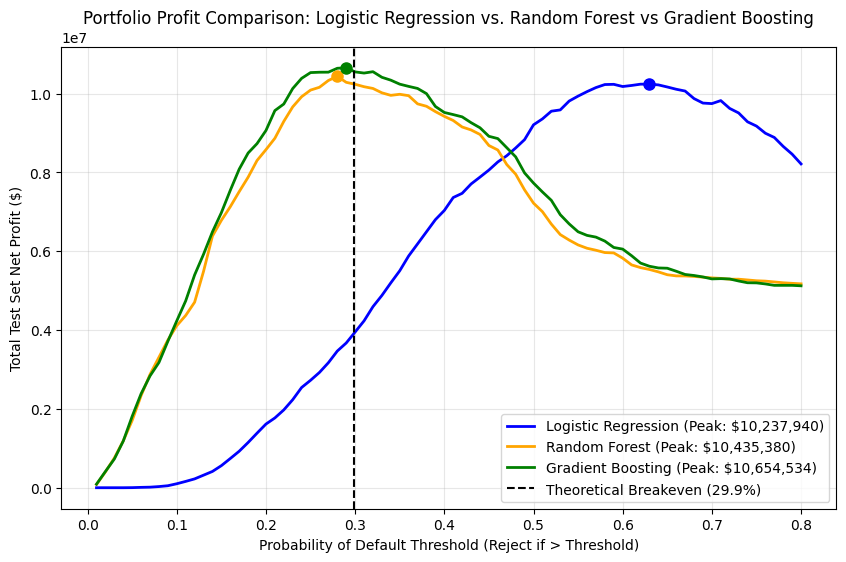

In [4]:
import matplotlib.pyplot as plt

thresholds = np.linspace(0.01, 0.8, 80)
lr_profits = []
rf_profits = []
gb_profits = []

print(len(log_reg_preds), len(rf_preds))

print(f'Profit if the bank approves everyone: ${test_financials["net_pnl"].sum():,.2f}')
print(
    f"Crystal ball profit (if the bank approved every full-payer and rejected every defaulter): ${test_financials.loc[~test_financials['did_default'], 'net_pnl'].sum():,.2f}"
)

for t in thresholds:
    # -- Logistic Regression --
    lr_mask = log_reg_preds["log_reg_prob"] <= t
    lr_profit = test_financials["net_pnl"][lr_mask].sum()
    lr_profits.append(lr_profit)

    # -- Random Forest --
    rf_mask = rf_preds["rf_prob"] <= t
    rf_profit = test_financials["net_pnl"][rf_mask].sum()
    rf_profits.append(rf_profit)

    # -- Gradient Boosting --
    gb_mask = gb_preds["gb_prob"] <= t
    gb_profit = test_financials["net_pnl"][gb_mask].sum()
    gb_profits.append(gb_profit)

max_lr_profit = max(lr_profits)
best_lr_threshold = thresholds[lr_profits.index(max_lr_profit)]

max_rf_profit = max(rf_profits)
best_rf_threshold = thresholds[rf_profits.index(max_rf_profit)]

max_gb_profit = max(gb_profits)
best_gb_threshold = thresholds[gb_profits.index(max_gb_profit)]

print(
    f"Logistic Regression Peak Profit: ${max_lr_profit:,.2f} (at threshold {best_lr_threshold*100:.1f}%)"
)
print(
    f"Random Forest Peak Profit: ${max_rf_profit:,.2f} (at threshold {best_rf_threshold*100:.1f}%)"
)
print(
    f"Gradient Boosting Peak Profit: ${max_gb_profit:,.2f} (at threshold {best_gb_threshold*100:.1f}%)"
)

plt.figure(figsize=(10, 6))
plt.plot(
    thresholds,
    lr_profits,
    label=f"Logistic Regression (Peak: ${max_lr_profit:,.0f})",
    color="blue",
    linewidth=2,
)
plt.plot(
    thresholds,
    rf_profits,
    label=f"Random Forest (Peak: ${max_rf_profit:,.0f})",
    color="orange",
    linewidth=2,
)
plt.plot(
    thresholds,
    gb_profits,
    label=f"Gradient Boosting (Peak: ${max_gb_profit:,.0f})",
    color="green",
    linewidth=2,
)

plt.axvline(
    x=0.299, color="black", linestyle="--", label="Theoretical Breakeven (29.9%)"
)

plt.plot(best_lr_threshold, max_lr_profit, marker="o", color="blue", markersize=8)
plt.plot(best_rf_threshold, max_rf_profit, marker="o", color="orange", markersize=8)
plt.plot(best_gb_threshold, max_gb_profit, marker="o", color="green", markersize=8)

plt.title(
    "Portfolio Profit Comparison: Logistic Regression vs. Random Forest vs Gradient Boosting"
)
plt.xlabel("Probability of Default Threshold (Reject if > Threshold)")
plt.ylabel("Total Test Set Net Profit ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Results and Discussion

There are a couple of things to discuss here.  
First, the Logistic Regression and Random Forest models each achieved similar profit peaks, though they had vastly different approval thresholds at their peaks. The maximum possible profit that could've been made was around $30M, and these models made around a third of that. And it was proven that the models are better than the foundational, naive strategy of just approving everyone, because that strategy made just $5M.

It is interesting to note that the Logistic Regression's peak profit was achieved at the threshold of 28.0%, because that's very close to the theoretically optimal cutoff of 29.9% that we calculated using expected value, with the idea that any borrower with a default probability of above 29.9% had a negative expected value. The possible reason the peak wasn't exactly on 29.9% could be because there are only 20% the same volume of loans in this dataset, and the distribution could be different compared to when we calculated that 29.9%.


before any changes:

Profit if the bank approves everyone: $5,075,169.18  
Crystal ball profit (if the bank approved every full-payer and rejected every defaulter): $30,026,176.63  
Logistic Regression Peak Profit: $10,364,610.55 (at threshold 64.0%)  
Random Forest Peak Profit: $10,461,409.24 (at threshold 28.0%)  
Gradient Boosting Peak Profit: $10,620,973.86 (at threshold 31.0%)
